In [1]:
import nibabel as nib
import numpy as np
import hippomaps as hm
import pandas as pd
from glob import glob

In [2]:
# locate input data
pet_dir = '/data/mica3/MICA-PET/derivatives_trc-mk6240_desc-REP/micapet/'
hippunfold_dir = '/data/mica3/BIDS_MICs/derivatives/hippunfold_v1.3.0/hippunfold'

# define which subjects and surfaces to examine
hemis = ['L','R']
labels = ['hipp','dentate']
den = '0p5mm'
ses='ses-01'

# get expected number of vertices and their indices
nV,iV = hm.config.get_nVertices(labels,den)

features = ['Tau', 'thickness', 'surfarea']

In [3]:
sheets = pd.read_excel('Tau-Thaera.xlsx', sheet_name=None)
df = pd.concat(sheets.values(), axis=1)
# clean column names
df.columns = df.columns.str.replace(r'[\s\xa0]+', '', regex=True)

# clean all string entries
df = df.applymap(
    lambda x: (
        x.replace('\xa0', '').replace(' ', '')
        if isinstance(x, str) else x
    )
)
df

/export03/data/tmp/ipykernel_1570869/1671305560.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(


,subj,Side,LH_HippunfoldHC,RH_HippunfoldHC,Wholebrain_CerebellarGM,HC,LH_HippunfoldHC,RH_HippunfoldHC,Wholebrain_CerebellarGM,PX-ID,age,HCmatched,subj
0,PX012,L,397.976564,351.794706,659.237885,HC010,587.578942,536.894669,1011.775328,PX012,35,HC052,PX012
1,PX017,L,524.740842,527.992334,811.232833,HC016,834.565915,873.144989,1197.404393,PX017,33,HC076,PX017
2,PX020,L,477.283975,490.932311,856.230191,HC027,567.851755,549.650106,844.406206,PX020,53,HC044,PX020
3,PX025,R,650.344830,566.735940,942.660493,HC036,564.908347,497.886926,830.340655,PX025,25,HC077,PX025
4,PX034,L,688.647051,564.068291,732.196985,HC039,951.008420,866.895412,1100.726249,PX034,54,HC160,PX034
5,PX036,L,460.562668,444.829706,668.066949,HC044,702.369498,598.742380,974.418904,PX036,26,HC081,PX036
6,PX044,R,782.197976,1015.179375,1154.418622,HC052,646.580566,593.955899,859.131559,PX044,44,HC027,PX044
7,PX048,R,276.989763,289.358540,516.062983,HC055,541.666403,494.941684,823.786447,PX048,29,HC088,PX048
8,PX050,R,748.463257,801.428693,1079.322454,HC058,719.385893,690.096892,978.097152,PX050,33,HC134,PX050
9,PX060,R,771.124353,688.320177,967.403884,HC065,551.483991,561.603883,806.104146,PX060,26,HC136,PX060


In [ ]:
allSubs = np.concatenate([
    df['PX-ID'],
    df['HCmatched']
])

allFeatureData = np.ones((nV,len(allSubs),len(features)))*np.nan
!mkdir -p tmp
for s,sub in enumerate(allSubs):
    for f,feature in enumerate(features):
        for l,label in enumerate(labels):
            if s > len(df['PX-ID'])-1:
                s2 = s - len(df['PX-ID'])-1 # repeat sides
                h=1 # take control Wholebrain_CerebellarGM
            else:            
                s2 = s
                h=0
            surf = f'{hippunfold_dir}/sub-{sub}/{ses}/surf/sub-{sub}_{ses}_hemi-{df["Side"].to_numpy()[s2]}_space-T1w_den-0p5mm_label-{label}_midthickness.surf.gii'
            if feature == 'Tau':
                volname = f'{pet_dir}/sub-{sub}/{ses}/pet/sub-{sub}_{ses}_pet-mkAVG-t1w_ANTs-a-direct.nii.gz'
                cmd = f'wb_command -volume-to-surface-mapping {volname} {surf} tmp/sub-{sub}_{ses}_hemi-{df["Side"].to_numpy()[s2]}_{feature}.shape.gii -trilinear'
                !{cmd}
                cmd = f'wb_command -metric-smoothing {surf} tmp/sub-{sub}_{ses}_hemi-{df["Side"].to_numpy()[s2]}_{feature}.shape.gii 2 tmp/sub-{sub}_{ses}_hemi-{df["Side"].to_numpy()[s2]}_{feature}_smooth.shape.gii'
                !{cmd}
                tau = nib.load(f'tmp/sub-{sub}_{ses}_hemi-{df["Side"].to_numpy()[s2]}_{feature}_smooth.shape.gii').darrays[0].data
                allFeatureData[iV[l],s,f] = tau / df["Wholebrain_CerebellarGM"].to_numpy()[s2,h]
            elif feature=='thickness' or feature == 'surfarea':
                if feature=='thickness' and label=='dentate': #thickness is not computed for dentate, so skip
                    continue
                cmd = f'wb_command -metric-smoothing {surf} {hippunfold_dir}/sub-{sub}/{ses}/surf/sub-{sub}_{ses}_hemi-{df["Side"].to_numpy()[s2]}_space-T1w_den-0p5mm_label-{label}_{feature}.shape.gii 2 tmp/sub-{sub}_{ses}_hemi-{df["Side"].to_numpy()[s2]}_{feature}_smooth.shape.gii'
                !{cmd}
                allFeatureData[iV[l],s,f] = nib.load(f'tmp/sub-{sub}_{ses}_hemi-{df["Side"].to_numpy()[s2]}_{feature}_smooth.shape.gii').darrays[0].data

!rm -rf tmp*

/export03/data/tmp/ipykernel_1152558/2595778686.py:6: RuntimeWarning: Mean of empty slice
  m  = np.nanmean(allFeatureData[:, hc, :], axis=1, keepdims=True)
/host/cassio/export03/data/opt/miniconda3/envs/hippunfold-dev/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/export03/data/tmp/ipykernel_1152558/2595778686.py:14: RuntimeWarning: Mean of empty slice
  hm.plotting.surfplot_canonical_foldunfold(np.nanmean(caseCtrl_diff,axis=1),labels=labels, hemis='L', tighten_cwindow=False, color_range='sym', color_bar='right', cmap = 'bwr', share='row', den=den, embed_nb=True)
/host/cassio/export03/data/opt/miniconda3/envs/hippunfold-dev/lib/python3.12/site-packages/brainspace/plotting/base.py:287: UserWarning: Interactive mode requires 'panel'. Setting 'interactive=False'
  warnings.warn("Interactive mode requires 'panel'. "


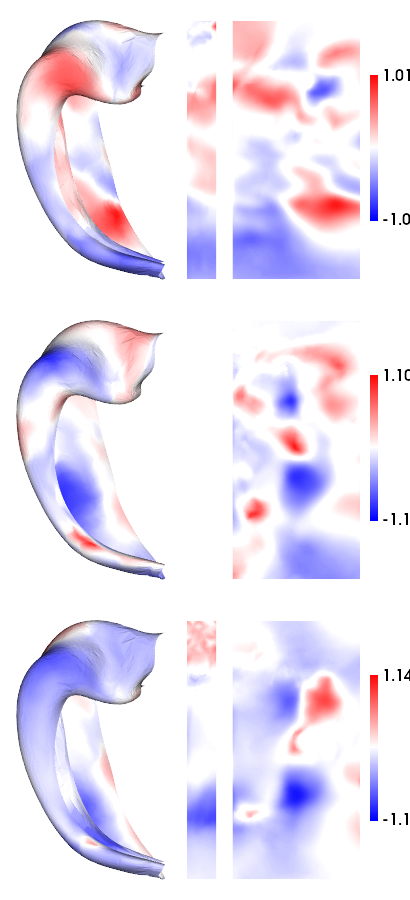

In [ ]:
isPX = np.array([s.startswith("PX") for s in allSubs])

hc = ~isPX
px = isPX

m  = np.nanmean(allFeatureData[:, hc, :], axis=1, keepdims=True)
sd = np.nanstd(allFeatureData[:, hc, :], axis=1, keepdims=True)

caseCtrl_diff = allFeatureData[:, px, :].copy()
caseCtrl_diff = (
    caseCtrl_diff - m
) / sd

hm.plotting.surfplot_canonical_foldunfold(np.nanmean(caseCtrl_diff,axis=1),labels=labels, hemis='L', tighten_cwindow=False, color_range='sym', color_bar='right', cmap = 'bwr', share='row', den=den, embed_nb=True)

In [ ]:
from scipy.stats import ttest_1samp
wholesurf = np.mean(caseCtrl_diff[:,:,0], axis=0)

tstat, p_two = ttest_1samp(wholesurf, 0.0)

print('Whole surface:')
print(f't={tstat:.3f}, p={p_two:.3f}')

Whole surface:
t=0.275, p=0.786


In [ ]:
iV

[range(0, 7262), range(7262, 9050)]

In [ ]:
iV[1][1] - iV[0][1]

7262

In [ ]:
subfields = nib.load(f'{hippunfold_dir}/sub-{sub}/{ses}/surf/sub-{sub}_{ses}_hemi-{df["Side"].to_numpy()[s2]}_space-T1w_den-0p5mm_label-hipp_atlas-multihist7_subfields.label.gii').darrays[0].data
subfields = np.hstack([subfields, np.ones(iV[1][-1] - iV[1][0] +1)*6]) # add dg
subfields.shape

(9050,)

In [ ]:
import numpy as np
import pandas as pd
from statsmodels.stats.multitest import fdrcorrection

# -----------------------------------
# names
# -----------------------------------
feature_names = ['Tau', 'thickness', 'surfarea']

subfield_names = {
    1: 'subiculum',
    2: 'CA1',
    3: 'CA2',
    4: 'CA3',
    5: 'CA4'
}
subfield_groups = {
    "subiculum": [1],
    "CA1-3": [2, 3, 4],
    "DG+CA4": [5, 6],
}

# -----------------------------------
# stats
# -----------------------------------
results = []


for sf_name, sf_ids in subfield_groups.items():

    mask = np.isin(subfields, sf_ids)

    for feat_idx, feat_name in enumerate(feature_names):

        # average vertices → subject level
        subj_vals = np.nanmean(
            caseCtrl_diff[mask, :, feat_idx],
            axis=0
        )

        # one-sample t-test vs 0
        tstat, p_two = ttest_1samp(subj_vals, 0.0)

        results.append({
            "subfield": sf_name,
            "feature": feat_name,
            "n": len(subj_vals),
            "mean": np.mean(subj_vals),
            "t": tstat,
            "p": p_two,
        })

df2 = pd.DataFrame(results)

# -----------------------------------
# FDR correction 
# -----------------------------------
df2["p_fdr"] = fdrcorrection(df2["p"])[1]


In [ ]:
df2

,subfield,feature,n,mean,t,p,p_fdr
0,subiculum,Tau,25,0.031367,0.247278,0.806796,0.972833
1,subiculum,thickness,25,0.076510,0.451833,0.655446,0.972833
2,subiculum,surfarea,25,-0.000893,-0.006567,0.994814,0.994814
3,CA1-3,Tau,25,-0.016648,-0.172179,0.864740,0.972833
4,CA1-3,thickness,25,-0.128121,-0.872718,0.391465,0.704637
5,CA1-3,surfarea,25,-0.275242,-1.697991,0.102440,0.704637
6,DG+CA4,Tau,25,0.108495,0.999214,0.327660,0.704637
7,DG+CA4,thickness,25,-0.164322,-1.127347,0.270741,0.704637
8,DG+CA4,surfarea,25,-0.223231,-1.344653,0.191309,0.704637


In [ ]:
sf_name

[1]

In [ ]:
# -----------------------------------
# subjects × subfields table (feature 0)
# -----------------------------------
feat_idx = 0  # Tau

subfield_table = {}

for sf_name, sf_ids in subfield_groups.items():

    mask = np.isin(subfields, sf_ids)

    # vertex → subject average
    subj_vals = np.nanmean(
        caseCtrl_diff[mask, :, feat_idx],
        axis=0
    )

    subfield_table[sf_name] = np.array(subj_vals)

# build dataframe
df_subj_sf = pd.DataFrame(
    subfield_table,
    index=allSubs[px]
)

print(df_subj_sf)

       subiculum     CA1-3    DG+CA4
PX012  -0.684643 -0.362405 -0.078598
PX017  -0.233816  0.080911 -0.299951
PX020  -0.387859 -0.858508 -0.676873
PX025  -0.611279 -0.402418 -0.089896
PX034   1.146345  0.644004  1.413848
PX036  -0.116020 -0.239876  0.283849
PX044   0.616195  0.744192  1.143735
PX048   0.165725 -0.779656 -0.762780
PX050   0.283266  0.153734  0.362089
PX060  -0.055643  0.103584 -0.151098
PX063   1.922110  1.082637  0.732871
PX067  -0.203843  0.104065  0.130332
PX080   1.049585  0.529433  0.323904
PX081  -0.104310 -0.133761 -0.281088
PX094   0.024258 -0.196315 -0.652088
PX122  -0.158884 -0.340626 -0.485034
PX123   0.025417 -0.241341  0.071887
PX124  -0.784688 -0.700783  0.073269
PX143  -0.222217  0.084020  0.006053
PX144   0.102419  0.118707  0.555341
PX145  -0.952586 -0.274828 -0.285172
PX153  -0.289706 -0.235138 -0.145380
PX168  -0.310072 -0.274327  0.318238
PX174   0.371000  0.588963  0.735060
PX176   0.193413  0.389540  0.469860


In [ ]:
summary_rows = []
pd.set_option("display.expand_frame_repr", False)
for sf in df2['subfield'].unique():

    row = {"subfield": sf}

    for feat in feature_names:
        r = df2[(df2.subfield == sf) & (df2.feature == feat)].iloc[0]

        row[feat] = (
            f"{r['mean']:.3f} "
            f"(t={r['t']:.2f}, p={r['p_fdr']:.3f})"
        )

    summary_rows.append(row)

summary_table = pd.DataFrame(summary_rows).set_index("subfield")

print(summary_table)

                                 Tau                  thickness                   surfarea
subfield                                                                                  
subiculum    0.031 (t=0.25, p=0.973)    0.077 (t=0.45, p=0.973)  -0.001 (t=-0.01, p=0.995)
CA1-3      -0.017 (t=-0.17, p=0.973)  -0.128 (t=-0.87, p=0.705)  -0.275 (t=-1.70, p=0.705)
DG+CA4       0.108 (t=1.00, p=0.705)  -0.164 (t=-1.13, p=0.705)  -0.223 (t=-1.34, p=0.705)


In [ ]:
subj_vals

array([-0.37350281,  1.48449875, -0.62552596,  1.12227772,  1.23908283,
       -0.25781785, -1.37239256, -0.37319916, -0.51861541, -0.75267958,
       -0.06478404, -0.36232603,  0.49479539,  0.37794055, -0.450968  ,
       -0.32568482, -0.68695554, -0.42700214, -1.00178049, -0.67848709,
       -0.5816055 , -0.88452304, -0.29245316, -0.3260245 , -1.76959124])

In [ ]:
# -----------------------------------
# print raw Tau SUVR by subject and subfield group
# -----------------------------------
feat_idx = feature_names.index('Tau')

suvr_rows = []

for subj_idx, subj in enumerate(allSubs):

    row = {'subject': subj}

    for sf_name, sf_ids in subfield_groups.items():

        mask = np.isin(subfields, sf_ids)
        row[sf_name] = np.nanmean(allFeatureData[mask, subj_idx, feat_idx])

    suvr_rows.append(row)

df_suvr_subfields = pd.DataFrame(suvr_rows)
df_suvr_subfields = df_suvr_subfields[['subject', *subfield_groups.keys()]]

pd.set_option('display.max_rows', None)
pd.set_option('display.expand_frame_repr', False)

print('Tau SUVR values by hippocampal subfield grouping:')
print(df_suvr_subfields.to_string(index=False))

df_suvr_subfields
